In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/sf-crime/train.csv.zip
/kaggle/input/competitions/sf-crime/sampleSubmission.csv.zip
/kaggle/input/competitions/sf-crime/test.csv.zip


In [2]:

import os
import sys
import warnings
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from datetime import datetime, timedelta
import folium
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")

# Create directories for outputs
os.makedirs('/kaggle/working/outputs', exist_ok=True)
os.makedirs('/kaggle/working/visualizations', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)


print(" CRIME INTELLIGENCE PIPELINE")

print("San Francisco Crime Analytics")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


 CRIME INTELLIGENCE PIPELINE
San Francisco Crime Analytics
Started at: 2026-04-04 13:00:08


# SECTION 1: DATA LOADING AND INITIAL EXPLORATION

In [3]:


# Load training data
train_path = '/kaggle/input/competitions/sf-crime/train.csv.zip'
test_path = '/kaggle/input/competitions/sf-crime/test.csv.zip'
sample_path = '/kaggle/input/competitions/sf-crime/sampleSubmission.csv.zip'

print("Loading training data...")
df = pd.read_csv(train_path)
print(f" Training data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Load test data
print("Loading test data...")
test_df = pd.read_csv(test_path)
print(f" Test data loaded: {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")

# Load sample submission
sample_sub = pd.read_csv(sample_path)
print(f" Sample submission loaded: {sample_sub.shape[0]:,} rows")

print("\n Initial Data Overview:")
print(f"  Date range in training: {pd.to_datetime(df['Dates']).min()} to {pd.to_datetime(df['Dates']).max()}")
print(f"  Unique crime categories: {df['Category'].nunique()}")
print(f"  Unique police districts: {df['PdDistrict'].nunique()}")


Loading training data...
 Training data loaded: 878,049 rows, 9 columns
Loading test data...
 Test data loaded: 884,262 rows, 7 columns
 Sample submission loaded: 884,262 rows

 Initial Data Overview:
  Date range in training: 2003-01-06 00:01:00 to 2015-05-13 23:53:00
  Unique crime categories: 39
  Unique police districts: 10


# SECTION 2: DATA CLEANING AND PREPROCESSING

In [4]:

def clean_dataframe(df, is_train=True):
    """Clean and preprocess the dataframe"""
    df_clean = df.copy()
    
    # Standardize column names
    df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')
    
    # Handle missing values
    if is_train:
        df_clean = df_clean.dropna(subset=['dates', 'pddistrict', 'category'])
    else:
        df_clean = df_clean.dropna(subset=['dates', 'pddistrict'])
    
    # Convert dates
    df_clean['dates'] = pd.to_datetime(df_clean['dates'])
    
    # Extract temporal features
    df_clean['year'] = df_clean['dates'].dt.year
    df_clean['month'] = df_clean['dates'].dt.month
    df_clean['day'] = df_clean['dates'].dt.day
    df_clean['hour'] = df_clean['dates'].dt.hour
    df_clean['minute'] = df_clean['dates'].dt.minute
    df_clean['dayofweek_num'] = df_clean['dates'].dt.dayofweek
    df_clean['week_of_year'] = df_clean['dates'].dt.isocalendar().week
    df_clean['quarter'] = df_clean['dates'].dt.quarter
    df_clean['is_weekend'] = df_clean['dayofweek_num'].isin([5, 6]).astype(int)
    
    # Week start for aggregation
    df_clean['week_start'] = df_clean['dates'].dt.to_period('W').apply(lambda r: r.start_time)
    
    # Clean categorical columns
    if is_train:
        df_clean['category'] = df_clean['category'].str.strip().str.upper()
    df_clean['pddistrict'] = df_clean['pddistrict'].str.strip().str.upper()
    df_clean['dayofweek'] = df_clean['dayofweek'].str.strip().str.title()
    
    if 'resolution' in df_clean.columns:
        df_clean['resolution'] = df_clean['resolution'].str.strip().str.upper()
    
    # Filter valid coordinates (San Francisco bounding box)
    if 'x' in df_clean.columns and 'y' in df_clean.columns:
        df_clean = df_clean[
            (df_clean['x'].between(-123.0, -122.3)) & 
            (df_clean['y'].between(37.6, 37.9))
        ]
    
    return df_clean

# Clean training data
df_clean = clean_dataframe(df, is_train=True)
print(f" Training data cleaned: {df_clean.shape[0]:,} rows remaining")

# Clean test data
test_clean = clean_dataframe(test_df, is_train=False)
print(f" Test data cleaned: {test_clean.shape[0]:,} rows remaining")

# Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['dates', 'pddistrict', 'address', 'category'])
print(f" Removed {before - len(df_clean):,} duplicate records")

print("\n Data Quality Report:")
print(f"  Date range: {df_clean['dates'].min()} to {df_clean['dates'].max()}")
print(f"  Years covered: {sorted(df_clean['year'].unique())}")
print(f"  Hours range: {df_clean['hour'].min()} to {df_clean['hour'].max()}")


 Training data cleaned: 877,982 rows remaining
 Test data cleaned: 884,186 rows remaining
 Removed 65,568 duplicate records

 Data Quality Report:
  Date range: 2003-01-06 00:01:00 to 2015-05-13 23:53:00
  Years covered: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]
  Hours range: 0 to 23


# SECTION 3: TIME SERIES ANALYSIS & ANOMALY DETECTION

In [5]:

# Weekly aggregation
weekly = (
    df_clean.groupby('week_start')
    .size()
    .reset_index(name='crime_count')
    .sort_values('week_start')
    .reset_index(drop=True)
)

# Calculate metrics
weekly['prev_week_count'] = weekly['crime_count'].shift(1)
weekly['delta'] = weekly['crime_count'] - weekly['prev_week_count']
weekly['pct_change'] = (weekly['delta'] / weekly['prev_week_count'] * 100).round(2)
weekly['rolling_mean_4wk'] = weekly['crime_count'].rolling(4, min_periods=1).mean()
weekly['rolling_std_4wk'] = weekly['crime_count'].rolling(4, min_periods=1).std()

# Z-score anomaly detection
weekly['z_score'] = (weekly['crime_count'] - weekly['rolling_mean_4wk']) / weekly['rolling_std_4wk']
weekly['z_score'] = weekly['z_score'].fillna(0)
weekly['is_anomaly'] = weekly['z_score'].abs() > 2
weekly['anomaly_type'] = np.where(
    weekly['z_score'] > 2, 'HIGH_SPIKE',
    np.where(weekly['z_score'] < -2, 'LOW_SPIKE', 'NORMAL')
)

# Monthly aggregation
monthly = df_clean.groupby(['year', 'month']).size().reset_index(name='crime_count')
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

# Hourly patterns
hourly_pattern = df_clean.groupby('hour').size().reset_index(name='crime_count')
peak_hour = hourly_pattern.loc[hourly_pattern['crime_count'].idxmax(), 'hour']

# Day of week patterns
dow_pattern = df_clean.groupby('dayofweek').size().reset_index(name='crime_count')
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_pattern['dayofweek'] = pd.Categorical(dow_pattern['dayofweek'], categories=dow_order, ordered=True)
dow_pattern = dow_pattern.sort_values('dayofweek')

print(f" Weekly analysis complete: {len(weekly)} weeks analyzed")
print(f" Anomalies detected: {weekly['is_anomaly'].sum()} weeks")
print(f" Peak crime hour: {peak_hour}:00")
print(f" Busiest day: {dow_pattern.loc[dow_pattern['crime_count'].idxmax(), 'dayofweek']}")


 Weekly analysis complete: 322 weeks analyzed
 Anomalies detected: 0 weeks
 Peak crime hour: 18:00
 Busiest day: Friday


# SECTION 4: VISUALIZATION - TIME SERIES

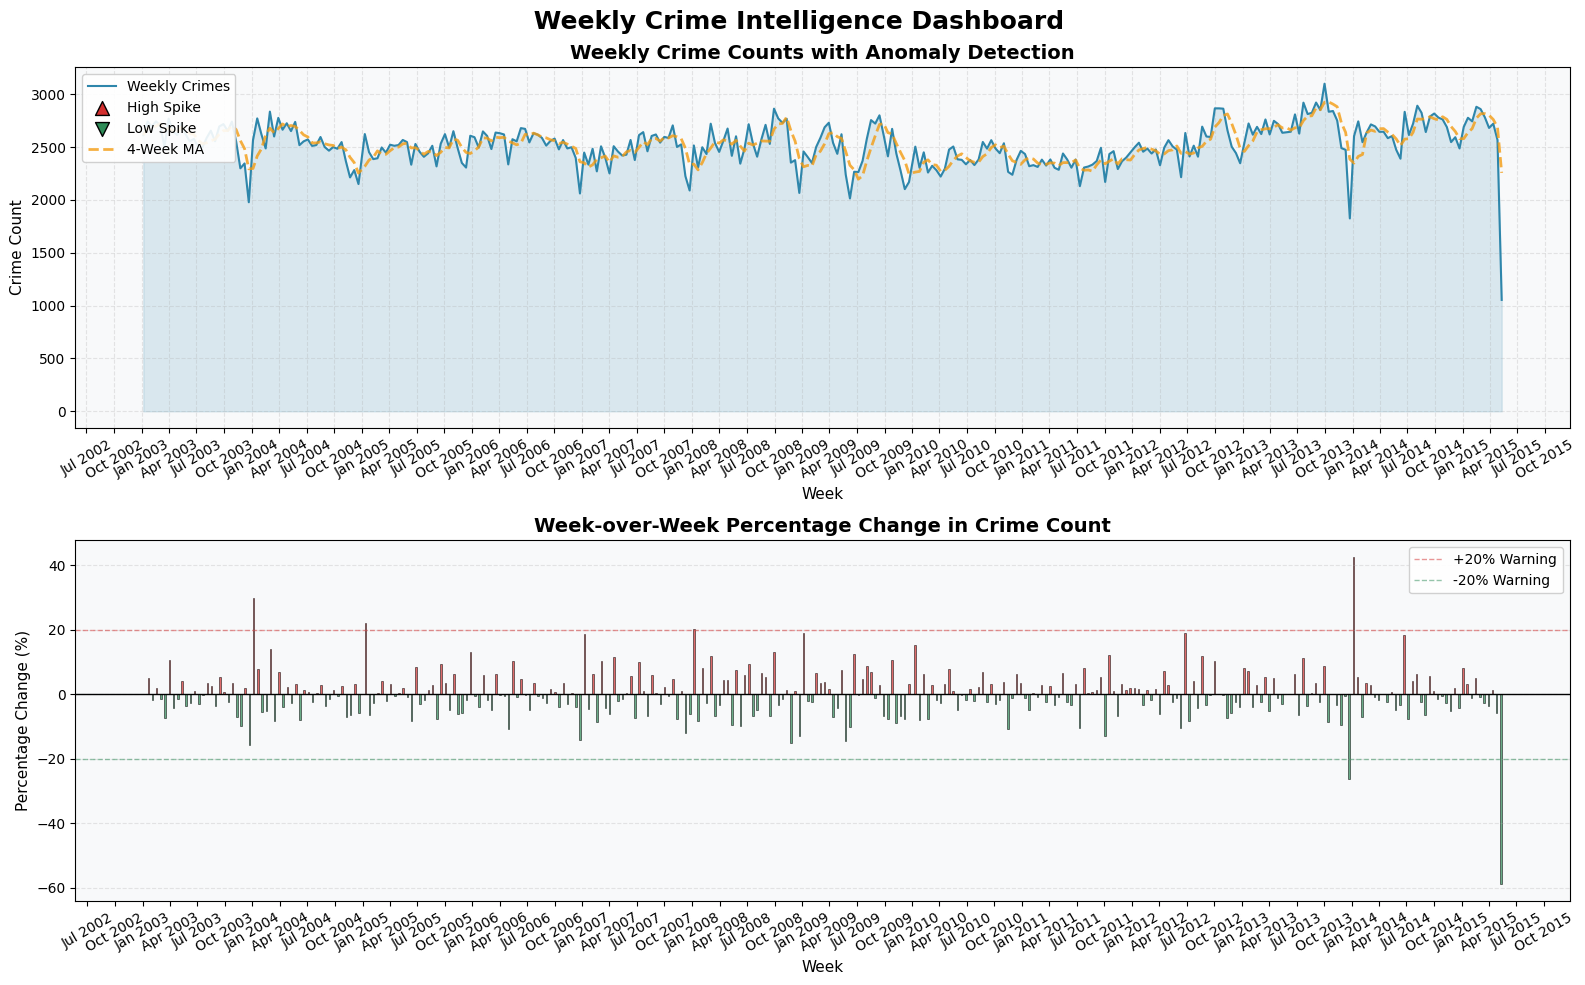

 Weekly crime dashboard saved


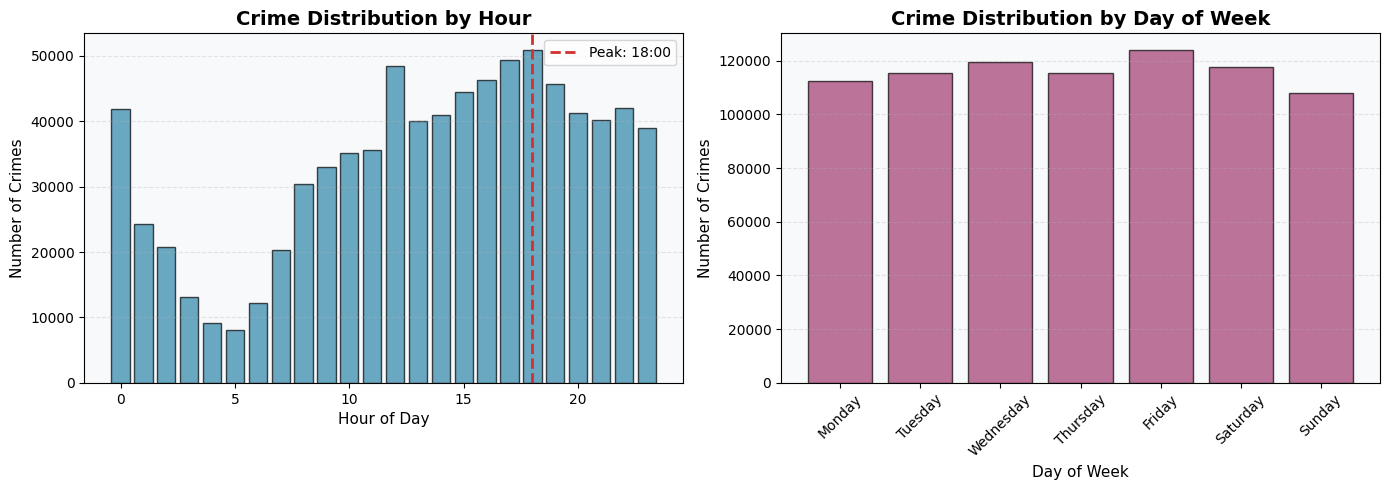

 Temporal patterns visualization saved


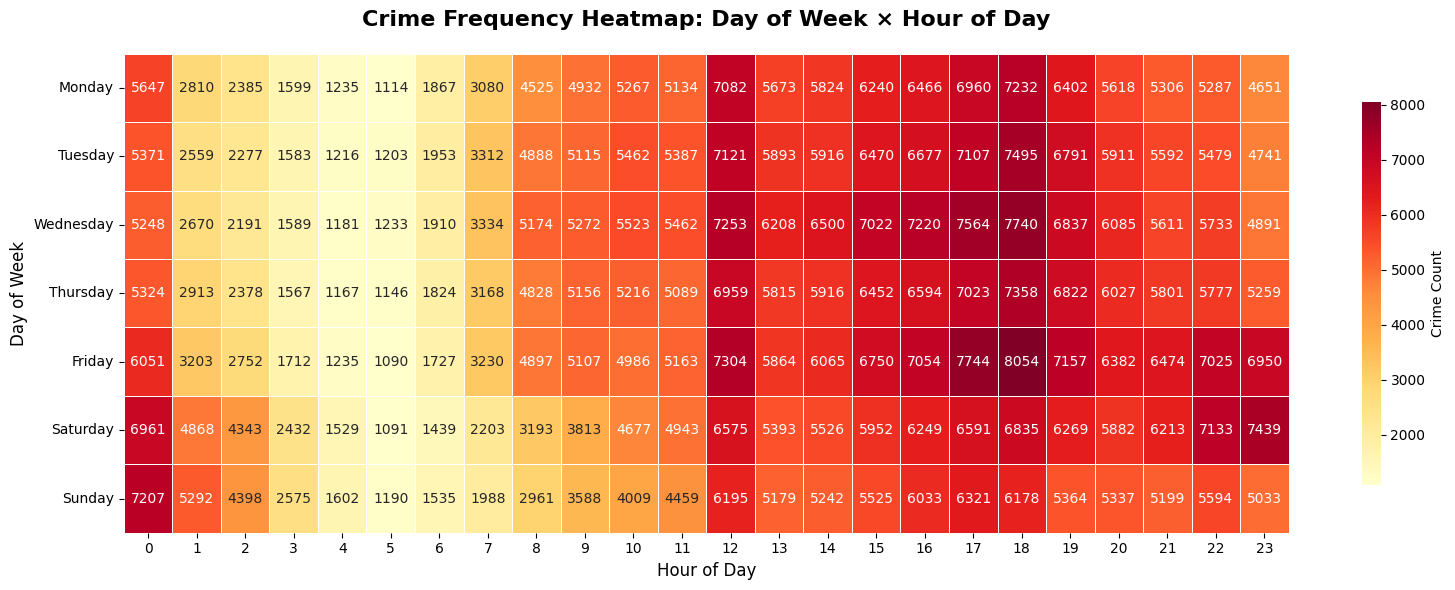

 Day-Hour heatmap saved


In [6]:


# Figure 1: Weekly Crime Trends with Anomalies
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor='white')
fig.suptitle(' Weekly Crime Intelligence Dashboard', 
             fontsize=18, fontweight='bold', y=0.98)

# Plot 1: Weekly counts
ax1 = axes[0]
ax1.plot(weekly['week_start'], weekly['crime_count'], 
         color='#2E86AB', linewidth=1.5, label='Weekly Crimes', zorder=2)
ax1.fill_between(weekly['week_start'], weekly['crime_count'], 
                 alpha=0.15, color='#2E86AB')

# Highlight anomalies
anomalies = weekly[weekly['is_anomaly']]
high_anomalies = anomalies[anomalies['z_score'] > 0]
low_anomalies = anomalies[anomalies['z_score'] < 0]

ax1.scatter(high_anomalies['week_start'], high_anomalies['crime_count'], 
            color='#D32F2F', s=100, zorder=5, label='High Spike', marker='^', edgecolors='black')
ax1.scatter(low_anomalies['week_start'], low_anomalies['crime_count'], 
            color='#2E8B57', s=100, zorder=5, label='Low Spike', marker='v', edgecolors='black')

# Rolling average
ax1.plot(weekly['week_start'], weekly['rolling_mean_4wk'], '--', 
         color='#F39C12', linewidth=2, alpha=0.8, label='4-Week MA')

ax1.set_title('Weekly Crime Counts with Anomaly Detection', fontsize=14, fontweight='bold')
ax1.set_xlabel('Week', fontsize=11)
ax1.set_ylabel('Crime Count', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

# Plot 2: Percentage change
ax2 = axes[1]
colors = ['#D32F2F' if v > 0 else '#2E8B57' for v in weekly['pct_change'].fillna(0)]
ax2.bar(weekly['week_start'], weekly['pct_change'].fillna(0), 
        color=colors, width=5, alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1, linestyle='-')
ax2.axhline(20, color='#D32F2F', linewidth=1, linestyle='--', alpha=0.5, label='+20% Warning')
ax2.axhline(-20, color='#2E8B57', linewidth=1, linestyle='--', alpha=0.5, label='-20% Warning')

ax2.set_title('Week-over-Week Percentage Change in Crime Count', fontsize=14, fontweight='bold')
ax2.set_xlabel('Week', fontsize=11)
ax2.set_ylabel('Percentage Change (%)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/weekly_crime_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Weekly crime dashboard saved")

# Figure 2: Hourly and Daily Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Hourly pattern
ax1 = axes[0]
ax1.bar(hourly_pattern['hour'], hourly_pattern['crime_count'], 
        color='#2E86AB', edgecolor='black', alpha=0.7)
ax1.axvline(peak_hour, color='#D32F2F', linestyle='--', linewidth=2, label=f'Peak: {peak_hour}:00')
ax1.set_title('Crime Distribution by Hour', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Number of Crimes', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
ax1.set_facecolor('#f8f9fa')

# Day of week pattern
ax2 = axes[1]
ax2.bar(dow_pattern['dayofweek'], dow_pattern['crime_count'], 
        color='#A23B72', edgecolor='black', alpha=0.7)
ax2.set_title('Crime Distribution by Day of Week', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day of Week', fontsize=11)
ax2.set_ylabel('Number of Crimes', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Temporal patterns visualization saved")

# Figure 3: Day-Hour Heatmap
pivot = df_clean.pivot_table(
    index='dayofweek', 
    columns='hour', 
    values='category',
    aggfunc='count', 
    observed=True
)
pivot = pivot.reindex(dow_order)

fig, ax = plt.subplots(figsize=(16, 6), facecolor='white')
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.5, linecolor='white',
            annot=True, fmt='d', cbar_kws={'label': 'Crime Count', 'shrink': 0.8})
ax.set_title('Crime Frequency Heatmap: Day of Week × Hour of Day', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/day_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Day-Hour heatmap saved")


# SECTION 5: DISTRICT ANALYSIS & RANKING


 District Rankings:
 rank pddistrict  total_crimes  pct_of_total  crimes_per_day
    1   SOUTHERN        147338         18.14           32.67
    2    MISSION        110399         13.59           24.48
    3   NORTHERN         98554         12.13           21.85
    4    BAYVIEW         81622         10.05           18.10
    5    CENTRAL         81233         10.00           18.01
    6  INGLESIDE         72487          8.92           16.07
    7 TENDERLOIN         72475          8.92           16.07
    8    TARAVAL         60714          7.47           13.46
    9       PARK         45517          5.60           10.09
   10   RICHMOND         42075          5.18            9.33

 Top 5 Crime Categories by District (%):
category    LARCENY/THEFT  OTHER OFFENSES  NON-CRIMINAL  ASSAULT  VANDALISM
pddistrict                                                                 
BAYVIEW              12.2            19.5           7.3     10.5        6.4
CENTRAL              30.5            1

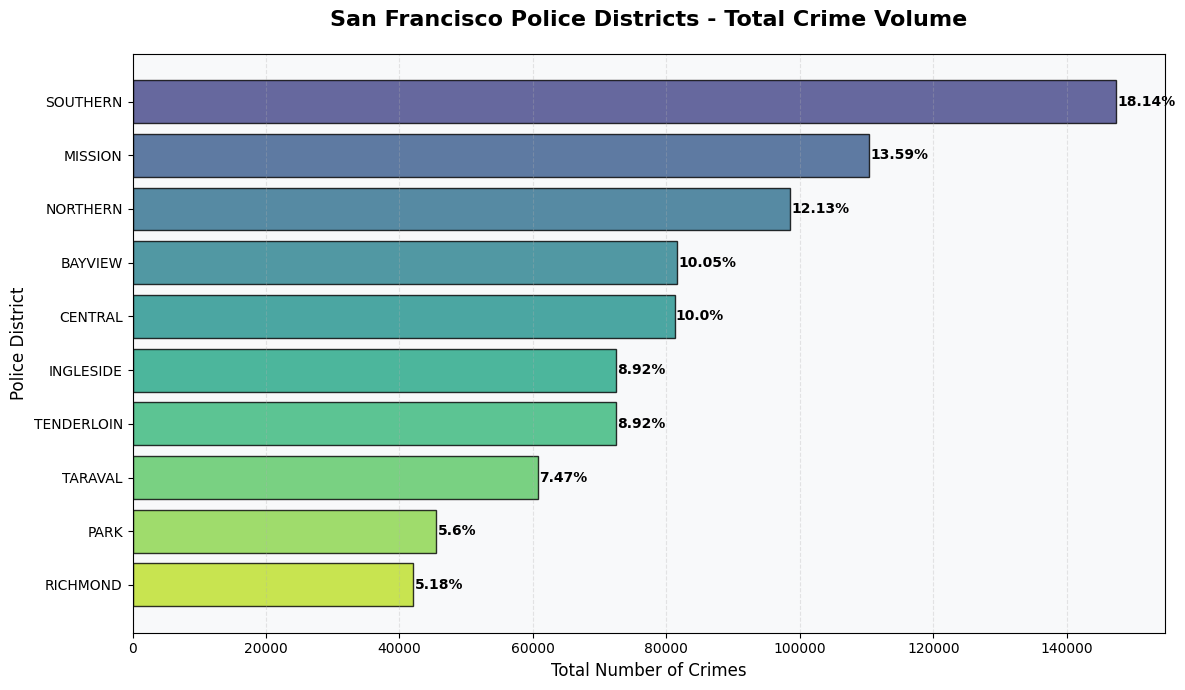

 District ranking visualization saved


In [7]:


# District statistics
district_stats = (
    df_clean.groupby('pddistrict')
    .agg({
        'category': ['count', 'nunique'],
        'y': 'mean',
        'x': 'mean',
        'dates': lambda x: (x.max() - x.min()).days
    })
    .round(2)
)

district_stats.columns = ['total_crimes', 'unique_categories', 'lat', 'lon', 'date_range_days']
district_stats = district_stats.reset_index()
district_stats['rank'] = district_stats['total_crimes'].rank(ascending=False).astype(int)
district_stats['pct_of_total'] = (district_stats['total_crimes'] / district_stats['total_crimes'].sum() * 100).round(2)
district_stats['crimes_per_day'] = (district_stats['total_crimes'] / district_stats['date_range_days']).round(2)
district_stats = district_stats.sort_values('rank')

print("\n District Rankings:")
print(district_stats[['rank', 'pddistrict', 'total_crimes', 'pct_of_total', 'crimes_per_day']].head(10).to_string(index=False))

# Top crime categories by district
district_categories = pd.crosstab(
    df_clean['pddistrict'], 
    df_clean['category'],
    normalize='index'
) * 100

top_categories = df_clean['category'].value_counts().head(5).index
district_top5 = district_categories[top_categories]

print("\n Top 5 Crime Categories by District (%):")
print(district_top5.head(10).round(1).to_string())

# Figure 4: District ranking bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(district_stats)))
bars = ax.barh(district_stats['pddistrict'], district_stats['total_crimes'], 
               color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels
for bar, pct in zip(bars, district_stats['pct_of_total']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('San Francisco Police Districts - Total Crime Volume', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Number of Crimes', fontsize=12)
ax.set_ylabel('Police District', fontsize=12)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, linestyle='--', axis='x')
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/district_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print(" District ranking visualization saved")

# SECTION 6: CRIME CATEGORY ANALYSIS


 Top 10 Crime Categories:
                 count most_common_district   avg_hour most_common_resolution
category                                                                     
LARCENY/THEFT   172546             SOUTHERN  14.416787                   NONE
OTHER OFFENSES  116683             SOUTHERN  13.083148          ARREST, CITED
NON-CRIMINAL     90367             SOUTHERN  13.093142                   NONE
ASSAULT          68486             SOUTHERN  12.717738                   NONE
VANDALISM        43746             SOUTHERN  13.604718                   NONE
VEHICLE THEFT    41468            INGLESIDE  14.751230                   NONE
DRUG/NARCOTIC    39767           TENDERLOIN  14.048910         ARREST, BOOKED
WARRANTS         39225             SOUTHERN  13.265647         ARREST, BOOKED
BURGLARY         36221             NORTHERN  12.953839                   NONE
SUSPICIOUS OCC   30937             SOUTHERN  12.646120                   NONE


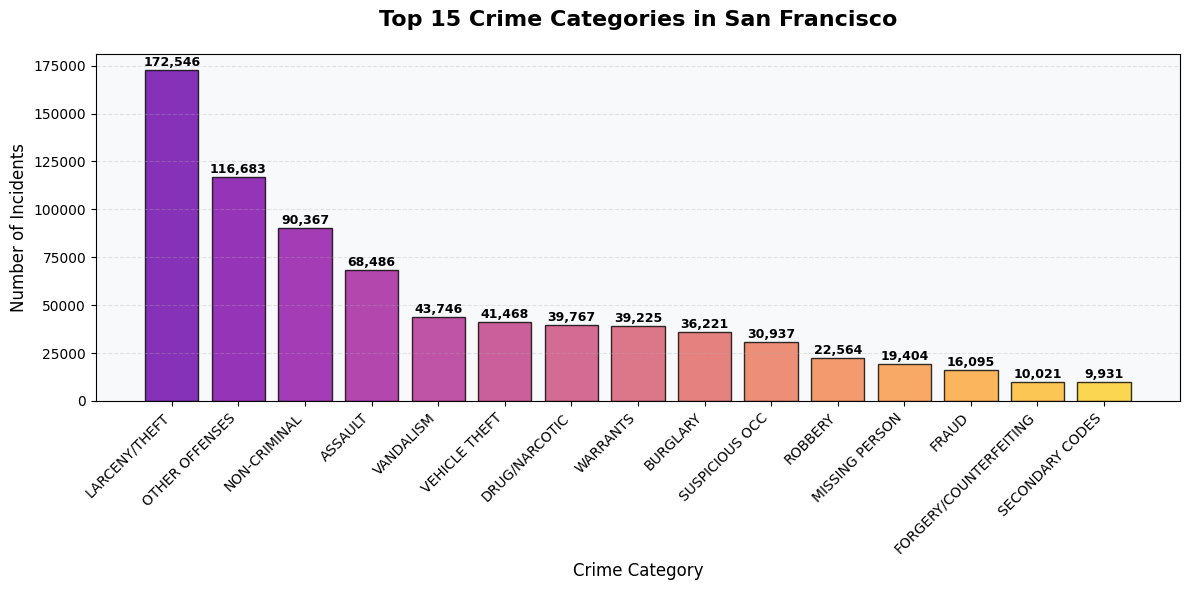

 Crime category visualization saved


In [8]:


# Category statistics
category_stats = (
    df_clean.groupby('category')
    .agg({
        'category': 'count',
        'pddistrict': lambda x: x.mode()[0] if len(x) > 0 else 'Unknown',
        'hour': 'mean',
        'resolution': lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'
    })
    .rename(columns={'category': 'count', 'pddistrict': 'most_common_district', 
                     'hour': 'avg_hour', 'resolution': 'most_common_resolution'})
    .sort_values('count', ascending=False)
)

print(f"\n Top 10 Crime Categories:")
print(category_stats.head(10).to_string())

# Figure 5: Top 15 crime categories
top_categories_plot = category_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_categories_plot)))
bars = ax.bar(range(len(top_categories_plot)), top_categories_plot['count'], 
              color=colors, edgecolor='black', alpha=0.8)

ax.set_xticks(range(len(top_categories_plot)))
ax.set_xticklabels(top_categories_plot.index, rotation=45, ha='right', fontsize=10)
ax.set_title('Top 15 Crime Categories in San Francisco', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Crime Category', fontsize=12)
ax.set_ylabel('Number of Incidents', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_facecolor('#f8f9fa')

# Add value labels
for bar, count in zip(bars, top_categories_plot['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/top_crime_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Crime category visualization saved")


# SECTION 7: GEOGRAPHICAL CLUSTERING

Finding optimal number of clusters...
✓ Optimal clusters: 4 (based on silhouette score)

 Cluster Statistics:
         count    x_mean   x_std   y_mean   y_std
cluster                                          
2        60644 -122.4150  0.0118  37.7821  0.0110
0        18592 -122.4041  0.0137  37.7397  0.0140
3        11729 -122.4716  0.0195  37.7673  0.0135
1         9035 -122.4507  0.0170  37.7242  0.0101


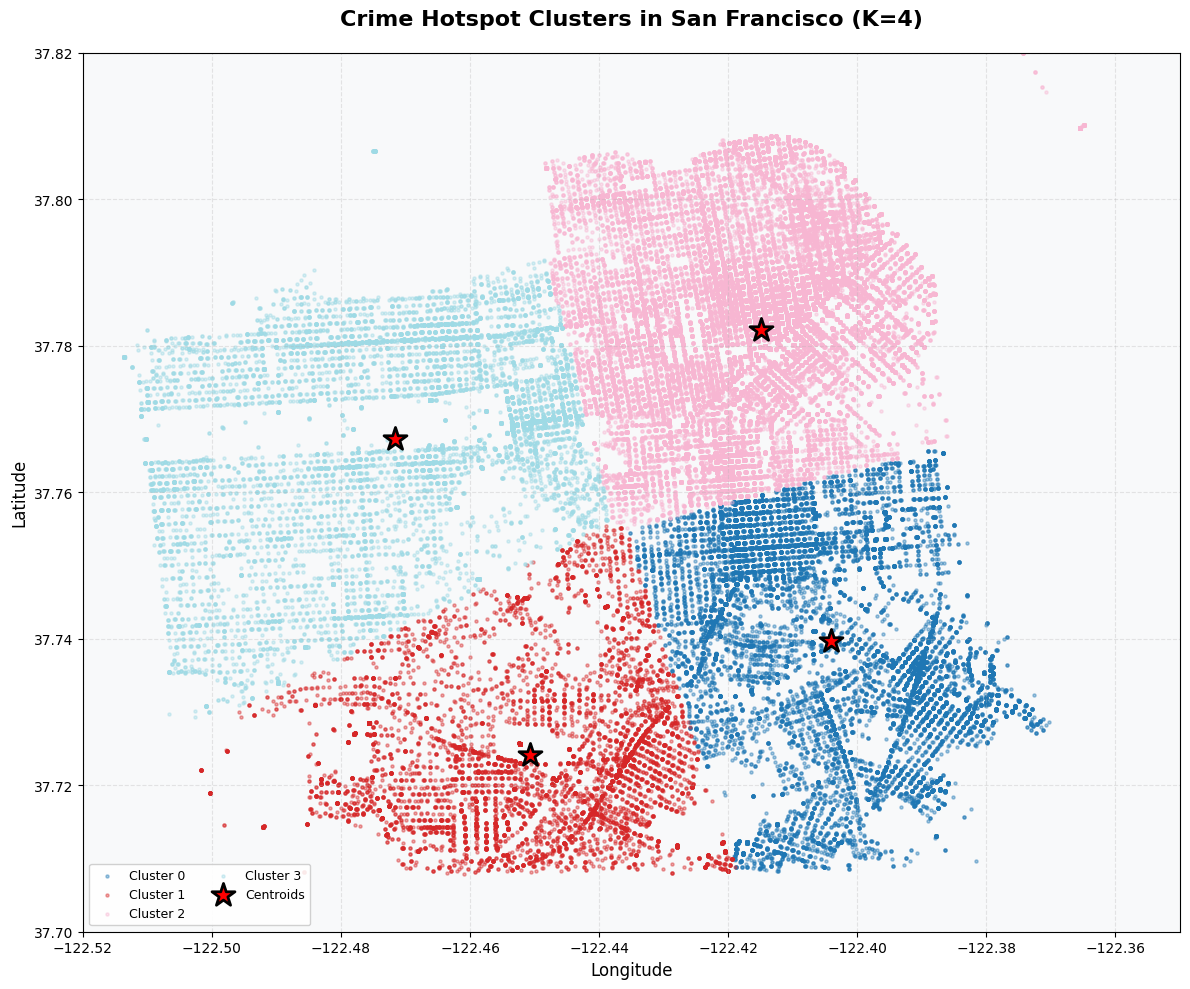

Cluster visualization saved


In [9]:

# Sample for clustering (use 100k points for speed)
sample_size = min(100000, len(df_clean))
sample_coords = df_clean[['x', 'y']].dropna().sample(sample_size, random_state=42)
coords = sample_coords.values

# Standardize coordinates
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Determine optimal K using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 13)

print("Finding optimal number of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords_scaled)
    inertias.append(kmeans.inertia_)
    if k >= 3:
        silhouette_scores.append(silhouette_score(coords_scaled, kmeans.labels_))

# Optimal K (elbow point or max silhouette)
optimal_k = K_range[np.argmax(silhouette_scores) + 2] if silhouette_scores else 8
print(f"✓ Optimal clusters: {optimal_k} (based on silhouette score)")

# Final clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(coords_scaled)
sample_coords['cluster'] = cluster_labels

# Cluster statistics
cluster_stats = sample_coords.groupby('cluster').agg({
    'x': ['count', 'mean', 'std'],
    'y': ['mean', 'std']
}).round(4)
cluster_stats.columns = ['count', 'x_mean', 'x_std', 'y_mean', 'y_std']
cluster_stats = cluster_stats.sort_values('count', ascending=False)

print("\n Cluster Statistics:")
print(cluster_stats.to_string())

# Figure 6: Cluster visualization
fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
ax.set_facecolor('#f8f9fa')

colors = plt.cm.tab20(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    mask = sample_coords['cluster'] == i
    ax.scatter(sample_coords.loc[mask, 'x'], sample_coords.loc[mask, 'y'],
               s=5, alpha=0.4, color=colors[i], label=f'Cluster {i}')

# Plot centroids
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
ax.scatter(centroids[:, 0], centroids[:, 1], s=300, marker='*', 
           c='red', edgecolors='black', linewidths=2, zorder=10, label='Centroids')

ax.set_title(f'Crime Hotspot Clusters in San Francisco (K={optimal_k})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='lower left', ncol=2, fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-122.52, -122.35)
ax.set_ylim(37.70, 37.82)

plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/crime_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster visualization saved")

# SECTION 8: INTERACTIVE MAP

In [10]:

# Create base map
sf_map = folium.Map(
    location=[37.77, -122.42], 
    zoom_start=12,
    tiles='CartoDB positron'
)

# Add district markers with scaled circles
max_crimes = district_stats['total_crimes'].max()
min_crimes = district_stats['total_crimes'].min()

def scale_radius(crimes):
    """Scale crime count to circle radius"""
    min_r, max_r = 8, 35
    return min_r + (crimes - min_crimes) / (max_crimes - min_crimes) * (max_r - min_r)

def get_color(rank):
    """Get color based on rank (red = high crime)"""
    colors = ['#D32F2F', '#E64A2E', '#F57C00', '#F9A825', '#FBC02D', 
              '#AFB42B', '#7CB342', '#43A047', '#388E3C', '#2E7D32']
    return colors[min(rank-1, len(colors)-1)]

# Add district circles
for _, row in district_stats.iterrows():
    radius = scale_radius(row['total_crimes'])
    color = get_color(row['rank'])
    
    popup_text = f"""
    <div style="font-family: monospace; min-width: 180px;">
        <b style="color: #2E86AB;">District {row['pddistrict']}</b><br>
        <b>Rank:</b> #{row['rank']}<br>
        <b>Total Crimes:</b> {row['total_crimes']:,}<br>
        <b>Share:</b> {row['pct_of_total']}%<br>
        <b>Crime Types:</b> {row['unique_categories']}<br>
        <b>Crimes/Day:</b> {row['crimes_per_day']}
    </div>
    """
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"{row['pddistrict']}: {row['total_crimes']:,} crimes",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        weight=2
    ).add_to(sf_map)

# Add cluster centroids
for i, centroid in enumerate(centroids):
    folium.Marker(
        location=[centroid[1], centroid[0]],
        popup=f"Hotspot Cluster {i}",
        icon=folium.Icon(color='red', icon='fire', prefix='fa'),
        tooltip=f"Cluster {i} Center"
    ).add_to(sf_map)

# Add title
title_html = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: white; padding: 10px 20px; 
     border-radius: 5px; font-family: Arial; font-size: 16px; 
     font-weight: bold; box-shadow: 0 2px 5px rgba(0,0,0,0.2);
     border: 2px solid #2E86AB;">
        San Francisco Crime Map
</div>
'''
sf_map.get_root().html.add_child(folium.Element(title_html))

# Save map
sf_map.save('/kaggle/working/outputs/sf_crime_map.html')
print(" Interactive map saved to /kaggle/working/outputs/sf_crime_map.html")

# Display map in notebook
display(sf_map)

 Interactive map saved to /kaggle/working/outputs/sf_crime_map.html


# SECTION 9: FEATURE ENGINEERING FOR MODELING

In [11]:


# Prepare features for predictive modeling
def create_features(df, is_train=True):
    """Create features for crime prediction"""
    features = pd.DataFrame()
    
    # Temporal features
    features['year'] = df['year']
    features['month'] = df['month']
    features['day'] = df['day']
    features['hour'] = df['hour']
    features['dayofweek'] = df['dayofweek_num']
    features['weekend'] = df['is_weekend']
    features['quarter'] = df['quarter']
    features['week_of_year'] = df['week_of_year']
    
    # Cyclical encoding for hour
    features['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    features['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Cyclical encoding for month
    features['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    features['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Cyclical encoding for day of week
    features['dow_sin'] = np.sin(2 * np.pi * df['dayofweek_num'] / 7)
    features['dow_cos'] = np.cos(2 * np.pi * df['dayofweek_num'] / 7)
    
    # District encoding
    le_district = LabelEncoder()
    features['district_code'] = le_district.fit_transform(df['pddistrict'])
    
    # Address features
    features['address_length'] = df['address'].str.len()
    features['has_block'] = df['address'].str.contains('block', case=False).astype(int)
    
    # Geographic features (if available)
    if 'x' in df.columns and 'y' in df.columns:
        features['longitude'] = df['x']
        features['latitude'] = df['y']
        
        # Cluster assignment
        coords_scaled_full = scaler.transform(df[['x', 'y']].fillna(df[['x', 'y']].mean()))
        features['cluster'] = kmeans_final.predict(coords_scaled_full)
    
    if is_train:
        features['category'] = df['category']
    
    return features

# Create features for training
train_features = create_features(df_clean, is_train=True)
print(f" Training features created: {train_features.shape}")

# Create features for test
test_features = create_features(test_clean, is_train=False)
print(f" Test features created: {test_features.shape}")

# Save features for modeling
train_features.to_csv('/kaggle/working/outputs/train_features.csv', index=False)
test_features.to_csv('/kaggle/working/outputs/test_features.csv', index=False)
print(" Features saved to CSV files")

 Training features created: (812414, 21)
 Test features created: (884186, 20)
 Features saved to CSV files


# SECTION 10: EXPLAINABLE INSIGHTS PANEL

In [12]:


# Calculate key metrics
total_crimes = len(df_clean)
unique_districts = df_clean['pddistrict'].nunique()
unique_categories = df_clean['category'].nunique()
date_range_days = (df_clean['dates'].max() - df_clean['dates'].min()).days
avg_daily_crimes = total_crimes / date_range_days

# Top district
top_district = district_stats.iloc[0]
worst_district = top_district['pddistrict']
worst_district_crimes = top_district['total_crimes']

# Top category
top_category = category_stats.index[0]
top_category_count = category_stats.iloc[0]['count']
top_category_pct = (top_category_count / total_crimes * 100)

# Anomaly stats
anomaly_weeks = weekly[weekly['is_anomaly']]
high_anomalies = anomaly_weeks[anomaly_weeks['z_score'] > 2]
worst_anomaly = high_anomalies.loc[high_anomalies['pct_change'].idxmax()] if len(high_anomalies) > 0 else None

# Time patterns
peak_hour_time = f"{peak_hour:02d}:00"
peak_day = dow_pattern.loc[dow_pattern['crime_count'].idxmax(), 'dayofweek']

# Cluster insights
largest_cluster = cluster_stats.iloc[0]
largest_cluster_id = int(largest_cluster.name)
largest_cluster_pct = (largest_cluster['count'] / len(sample_coords) * 100)

# Generate HTML panel
html_panel = f"""
<!DOCTYPE html>
<html>
<head>
<style>
    .insight-panel {{
        font-family: 'Segoe UI', Arial, sans-serif;
        max-width: 1000px;
        margin: 20px auto;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        border-radius: 15px;
        padding: 20px;
        color: white;
    }}
    .header {{
        text-align: center;
        padding: 20px;
        background: rgba(255,255,255,0.1);
        border-radius: 10px;
        margin-bottom: 20px;
    }}
    .header h1 {{
        margin: 0;
        font-size: 28px;
    }}
    .header p {{
        margin: 5px 0 0;
        opacity: 0.9;
    }}
    .grid {{
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
        gap: 15px;
        margin-bottom: 20px;
    }}
    .card {{
        background: rgba(255,255,255,0.15);
        backdrop-filter: blur(10px);
        border-radius: 10px;
        padding: 15px;
        transition: transform 0.3s;
    }}
    .card:hover {{
        transform: translateY(-5px);
    }}
    .card-title {{
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: 1px;
        opacity: 0.8;
        margin-bottom: 8px;
    }}
    .card-value {{
        font-size: 28px;
        font-weight: bold;
        margin-bottom: 5px;
    }}
    .card-sub {{
        font-size: 12px;
        opacity: 0.7;
    }}
    .insight-section {{
        background: rgba(0,0,0,0.2);
        border-radius: 10px;
        padding: 15px;
        margin-top: 20px;
    }}
    .insight-title {{
        font-size: 18px;
        font-weight: bold;
        margin-bottom: 15px;
        border-left: 3px solid #ffd700;
        padding-left: 10px;
    }}
    .insight-item {{
        margin-bottom: 12px;
        padding: 10px;
        background: rgba(255,255,255,0.1);
        border-radius: 8px;
    }}
    .badge {{
        display: inline-block;
        padding: 3px 8px;
        border-radius: 12px;
        font-size: 11px;
        font-weight: bold;
        margin-left: 8px;
    }}
    .badge-critical {{ background: #ff4757; }}
    .badge-warning {{ background: #ffa502; }}
    .badge-info {{ background: #1e90ff; }}
    .footer {{
        text-align: center;
        margin-top: 20px;
        padding-top: 15px;
        border-top: 1px solid rgba(255,255,255,0.2);
        font-size: 12px;
        opacity: 0.7;
    }}
</style>
</head>
<body>
<div class="insight-panel">
    <div class="header">
        <h1> Crime Intelligence Report</h1>
        <p>San Francisco Police Department | {df_clean['dates'].min().strftime('%B %d, %Y')} - {df_clean['dates'].max().strftime('%B %d, %Y')}</p>
    </div>
    
    <div class="grid">
        <div class="card">
            <div class="card-title"> Total Incidents</div>
            <div class="card-value">{total_crimes:,}</div>
            <div class="card-sub">Across {date_range_days} days</div>
        </div>
        <div class="card">
            <div class="card-title"> Police Districts</div>
            <div class="card-value">{unique_districts}</div>
            <div class="card-sub">{avg_daily_crimes:.0f} crimes/day avg</div>
        </div>
        <div class="card">
            <div class="card-title"> Crime Categories</div>
            <div class="card-value">{unique_categories}</div>
            <div class="card-sub">Unique offense types</div>
        </div>
        <div class="card">
            <div class="card-title"> Anomaly Weeks</div>
            <div class="card-value">{len(anomaly_weeks)}</div>
            <div class="card-sub">{len(high_anomalies)} high spikes</div>
        </div>
    </div>
    
    <div class="insight-section">
        <div class="insight-title"> Critical Insights</div>
        
        <div class="insight-item">
            <strong> Highest Crime District:</strong> {worst_district}
            <span class="badge badge-critical">RANK #1</span>
            <br>
            <small>{worst_district_crimes:,} total incidents ({district_stats.iloc[0]['pct_of_total']}% of all crimes)</small>
        </div>
        
        <div class="insight-item">
            <strong> Most Common Crime:</strong> {top_category}
            <span class="badge badge-warning">{top_category_pct:.1f}%</span>
            <br>
            <small>{top_category_count:,} reported incidents</small>
        </div>
        
        <div class="insight-item">
            <strong> Peak Crime Window:</strong> {peak_hour_time} on {peak_day}s
            <br>
            <small>Highest concentration of criminal activity</small>
        </div>
        
        <div class="insight-item">
            <strong> Largest Hotspot Cluster:</strong> Cluster {largest_cluster_id}
            <span class="badge badge-info">{largest_cluster_pct:.1f}%</span>
            <br>
            <small>{largest_cluster['count']:,} incidents in this geographical zone</small>
        </div>
"""

if worst_anomaly is not None:
    html_panel += f"""
        <div class="insight-item">
            <strong> Biggest Weekly Spike:</strong> Week of {worst_anomaly['week_start'].strftime('%B %d, %Y')}
            <span class="badge badge-critical">+{worst_anomaly['pct_change']:.1f}%</span>
            <br>
            <small>Z-score: {worst_anomaly['z_score']:.2f} (significantly above normal)</small>
        </div>
    """

html_panel += f"""
    </div>
    
    <div class="insight-section">
        <div class="insight-title"> Recommended Actions</div>
        
        <div class="insight-item">
            <strong> Resource Allocation:</strong> Increase patrol presence in {worst_district} district during {peak_hour_time}-{(peak_hour+2)%24:02d}:00 window
        </div>
        
        <div class="insight-item">
            <strong> Monitoring Protocol:</strong> Implement real-time alert system when weekly crime count exceeds 2 standard deviations from 4-week moving average
        </div>
        
        <div class="insight-item">
            <strong> Targeted Operations:</strong> Focus on {top_category} prevention in identified hotspot clusters
        </div>
        
        <div class="insight-item">
            <strong> Review Cycle:</strong> Re-evaluate district rankings and cluster shifts quarterly
        </div>
    </div>
    
    <div class="footer">
        Generated by Crime Intelligence System | Data Source: SFPD Crime Incident Reporting
    </div>
</div>
</body>
</html>
"""

# Save HTML panel
with open('/kaggle/working/outputs/crime_insights_panel.html', 'w') as f:
    f.write(html_panel)

# Display in notebook
display(HTML(html_panel))
print(" Insights panel saved to /kaggle/working/outputs/crime_insights_panel.html")


 Insights panel saved to /kaggle/working/outputs/crime_insights_panel.html


# SECTION 11: SAVE RESULTS AND SUMMARY

In [15]:


# Save weekly summary
weekly_summary = weekly[['week_start', 'crime_count', 'pct_change', 'z_score', 'anomaly_type']].copy()
weekly_summary.to_csv('/kaggle/working/outputs/weekly_crime_summary.csv', index=False)
print(" Weekly crime summary saved")

# Save district statistics
district_stats.to_csv('/kaggle/working/outputs/district_statistics.csv', index=False)
print("District statistics saved")

# Save category statistics
category_stats.to_csv('/kaggle/working/outputs/category_statistics.csv')
print(" Category statistics saved")

# Save cluster statistics
cluster_stats.to_csv('/kaggle/working/outputs/cluster_statistics.csv')
print(" Cluster statistics saved")

# Create a summary report
summary_report = f"""
 CRIME INTELLIGENCE REPORT

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET OVERVIEW

Total Records: {total_crimes:,}
Date Range: {df_clean['dates'].min()} to {df_clean['dates'].max()}
Time Span: {date_range_days} days
Police Districts: {unique_districts}
Crime Categories: {unique_categories}

TOP DISTRICTS
1. {district_stats.iloc[0]['pddistrict']}: {district_stats.iloc[0]['total_crimes']:,} crimes ({district_stats.iloc[0]['pct_of_total']}%)
2. {district_stats.iloc[1]['pddistrict']}: {district_stats.iloc[1]['total_crimes']:,} crimes ({district_stats.iloc[1]['pct_of_total']}%)
3. {district_stats.iloc[2]['pddistrict']}: {district_stats.iloc[2]['total_crimes']:,} crimes ({district_stats.iloc[2]['pct_of_total']}%)

TOP CRIME CATEGORIES

1. {category_stats.index[0]}: {category_stats.iloc[0]['count']:,}
2. {category_stats.index[1]}: {category_stats.iloc[1]['count']:,}
3. {category_stats.index[2]}: {category_stats.iloc[2]['count']:,}

TEMPORAL PATTERNS

Peak Hour: {peak_hour}:00
Peak Day: {peak_day}
Busiest Month: {df_clean.groupby('month').size().idxmax()}

ANOMALY DETECTION

Total Anomaly Weeks: {len(anomaly_weeks)}
High Spikes: {len(high_anomalies)}
Low Spikes: {len(anomaly_weeks) - len(high_anomalies)}

CLUSTERING RESULTS

Optimal Clusters: {optimal_k}
Largest Cluster: {largest_cluster_id} ({largest_cluster['count']:,} points)

OUTPUT FILES GENERATED

- Visualizations: /kaggle/working/visualizations/
- Interactive Map: /kaggle/working/outputs/sf_crime_map.html
- Insights Panel: /kaggle/working/outputs/crime_insights_panel.html
- Feature Files: /kaggle/working/outputs/train_features.csv, test_features.csv
- Summary Files: weekly_crime_summary.csv, district_statistics.csv, etc.

ANALYSIS COMPLETE
----------------
All analyses have been successfully completed and saved.
"""

with open('/kaggle/working/outputs/summary_report.txt', 'w') as f:
    f.write(summary_report)


print(" PIPELINE COMPLETE!")

print(summary_report)

print("\n All outputs saved to /kaggle/working/outputs/")
print(" Visualizations saved to /kaggle/working/visualizations/")
print(" Interactive map: /kaggle/working/outputs/sf_crime_map.html")
print(" Insights panel: /kaggle/working/outputs/crime_insights_panel.html")


 Weekly crime summary saved
District statistics saved
 Category statistics saved
 Cluster statistics saved
 PIPELINE COMPLETE!

 CRIME INTELLIGENCE REPORT

Generated: 2026-04-04 13:20:14

DATASET OVERVIEW

Total Records: 812,414
Date Range: 2003-01-06 00:01:00 to 2015-05-13 23:53:00
Time Span: 4510 days
Police Districts: 10
Crime Categories: 39

TOP DISTRICTS
1. SOUTHERN: 147,338 crimes (18.14%)
2. MISSION: 110,399 crimes (13.59%)
3. NORTHERN: 98,554 crimes (12.13%)

TOP CRIME CATEGORIES

1. LARCENY/THEFT: 172,546
2. OTHER OFFENSES: 116,683
3. NON-CRIMINAL: 90,367

TEMPORAL PATTERNS

Peak Hour: 18:00
Peak Day: Friday
Busiest Month: 10

ANOMALY DETECTION

Total Anomaly Weeks: 0
High Spikes: 0
Low Spikes: 0

CLUSTERING RESULTS

Optimal Clusters: 4
Largest Cluster: 2 (60,644.0 points)

OUTPUT FILES GENERATED

- Visualizations: /kaggle/working/visualizations/
- Interactive Map: /kaggle/working/outputs/sf_crime_map.html
- Insights Panel: /kaggle/working/outputs/crime_insights_panel.html
- F